<a href="https://colab.research.google.com/github/mahammadaftab/OpenEnv_Colab/blob/main/OpenEnv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install -q "transformers>=4.38" "datasets>=2.17" "accelerate>=0.27" \
             "trl>=0.10" "peft>=0.9" "bitsandbytes>=0.42"
!pip install -q matplotlib seaborn numpy

In [2]:
import re
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from trl import GRPOConfig, GRPOTrainer

print("torch:", torch.__version__)
print("device:", "cuda" if torch.cuda.is_available() else "cpu")

torch: 2.10.0+cpu
device: cpu


In [3]:
class CivicAIEnv:
    def __init__(self):
        self.reset()

    def reset(self):
        self.state_data = {
            "inflation":    np.random.uniform(5, 10),
            "employment":   np.random.uniform(0.6, 0.9),
            "health":       np.random.uniform(0.5, 0.9),
            "satisfaction": np.random.uniform(0.4, 0.8),
            "crime":        np.random.uniform(0.1, 0.4),
        }
        return self.state_data.copy()

    def step(self, action):
        self.state_data["inflation"]  -= action.get("tax", 0.5) * 0.1
        self.state_data["employment"] += action.get("jobs", 0.5) * 0.05
        self.state_data["health"]     += action.get("healthcare", 0.5) * 0.05
        for k in self.state_data:
            self.state_data[k] += np.random.normal(0, 0.01)
        return self.state_data.copy(), self.compute_reward()

    def compute_reward(self):
        s = self.state_data
        return (
            0.3 * (1 - abs(s["inflation"] - 4) / 10) +
            0.3 * s["employment"] +
            0.2 * s["health"] +
            0.2 * s["satisfaction"]
        )

env = CivicAIEnv()
print("Environment ready. Sample state:", env.reset())

Environment ready. Sample state: {'inflation': 6.378304481729322, 'employment': 0.7347560303751888, 'health': 0.6925830403123695, 'satisfaction': 0.6278013384891219, 'crime': 0.27401493751947614}


In [4]:
def make_prompt(state):
    return (
        "You are a policy maker. Current economic state:\n"
        f"  Inflation: {state['inflation']:.2f}\n"
        f"  Employment: {state['employment']:.2f}\n"
        f"  Health: {state['health']:.2f}\n"
        f"  Satisfaction: {state['satisfaction']:.2f}\n"
        f"  Crime: {state['crime']:.2f}\n\n"
        "Respond ONLY in this exact format:\n"
        "tax: 0.X, jobs: 0.X, healthcare: 0.X"
    )

# Generate 200 episodes worth of prompts as the training dataset
NUM_SAMPLES = 200
records = []
env_temp = CivicAIEnv()
for _ in range(NUM_SAMPLES):
    state = env_temp.reset()
    records.append({"prompt": make_prompt(state)})

train_dataset = Dataset.from_list(records)
print(f"Dataset ready: {len(train_dataset)} prompts")
print("Example prompt:\n", train_dataset[0]["prompt"])

Dataset ready: 200 prompts
Example prompt:
 You are a policy maker. Current economic state:
  Inflation: 5.28
  Employment: 0.75
  Health: 0.77
  Satisfaction: 0.54
  Crime: 0.27

Respond ONLY in this exact format:
tax: 0.X, jobs: 0.X, healthcare: 0.X


In [29]:
import re

def parse_action(text):
    def extract(key):
        # \d*\.?\d+ matches valid floats only — stops before a second dot
        m = re.search(rf"{key}\s*:\s*(\d*\.?\d+)", text)
        if m:
            try:
                return min(max(float(m.group(1)), 0.0), 1.0)
            except ValueError:
                return 0.5
        return 0.5

    return {
        "tax":        extract("tax"),
        "jobs":       extract("jobs"),
        "healthcare": extract("healthcare"),
    }

# Quick sanity check
print(parse_action("tax: 0.12., jobs: 0.8, healthcare: 0.4"))
# Should print: {'tax': 0.12, 'jobs': 0.8, 'healthcare': 0.4}

{'tax': 0.12, 'jobs': 0.8, 'healthcare': 0.4}


In [30]:
def civic_reward(prompts, completions, **kwargs):
    """
    GRPO reward function.
    completions: list of lists — each inner list is [{"role":"assistant","content":"..."}]
    Returns a list of float rewards.
    """
    rewards = []
    env_local = CivicAIEnv()

    for prompt, completion in zip(prompts, completions):
        # Extract text from completion message format
        if isinstance(completion, list) and len(completion) > 0:
            text = completion[0].get("content", "")
        else:
            text = str(completion)

        action = parse_action(text)

        # Simulate one environment step from a fresh random state
        env_local.reset()
        _, reward = env_local.step(action)

        # Bonus reward if output format is correct
        format_ok = bool(re.search(r"tax\s*:\s*[\d.]+", text) and
                         re.search(r"jobs\s*:\s*[\d.]+", text) and
                         re.search(r"healthcare\s*:\s*[\d.]+", text))
        reward += 0.1 if format_ok else -0.1

        rewards.append(float(reward))

    return rewards

# Sanity check
test_completions = [[{"role": "assistant", "content": "tax: 0.3, jobs: 0.7, healthcare: 0.5"}]]
test_prompts = ["dummy prompt"]
print("Test reward:", civic_reward(test_prompts, test_completions))

Test reward: [0.8009328921637223]


In [31]:
model_name = "gpt2"   # small enough for free Colab T4

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "left"   # required for causal LMs in GRPO

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float32,    # float32 for CPU; use bfloat16 on A100
)

print("Model loaded:", model_name)
print("Parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: gpt2
Parameters: 124.439808 M


In [32]:
import trl, inspect

print("TRL version:", trl.__version__)

# Print ALL valid GRPOConfig parameters so we know exactly what to use
from trl import GRPOConfig
sig = inspect.signature(GRPOConfig.__init__)
params = [p for p in sig.parameters if p != "self"]
print("\nValid GRPOConfig parameters:")
for p in params:
    print(" ", p)

TRL version: 1.2.0

Valid GRPOConfig parameters:
  output_dir
  do_train
  do_eval
  do_predict
  eval_strategy
  prediction_loss_only
  per_device_train_batch_size
  per_device_eval_batch_size
  gradient_accumulation_steps
  eval_accumulation_steps
  eval_delay
  torch_empty_cache_steps
  learning_rate
  weight_decay
  adam_beta1
  adam_beta2
  adam_epsilon
  max_grad_norm
  num_train_epochs
  max_steps
  lr_scheduler_type
  lr_scheduler_kwargs
  warmup_ratio
  warmup_steps
  log_level
  log_level_replica
  log_on_each_node
  logging_dir
  logging_strategy
  logging_first_step
  logging_steps
  logging_nan_inf_filter
  save_strategy
  save_steps
  save_total_limit
  enable_jit_checkpoint
  save_on_each_node
  save_only_model
  restore_callback_states_from_checkpoint
  use_cpu
  seed
  data_seed
  bf16
  fp16
  bf16_full_eval
  fp16_full_eval
  tf32
  local_rank
  ddp_backend
  debug
  dataloader_drop_last
  eval_steps
  dataloader_num_workers
  dataloader_prefetch_factor
  run_name
  

In [33]:
import trl, inspect, torch
from trl import GRPOConfig, GRPOTrainer

# ── 1. Detect hardware precision ──────────────────────────────
cuda_ok = torch.cuda.is_available()
if cuda_ok:
    cap      = torch.cuda.get_device_capability()
    use_bf16 = cap[0] >= 8       # A100/H100 only
    use_fp16 = not use_bf16      # T4/V100
else:
    use_bf16 = False
    use_fp16 = False             # CPU → fp32

print(f"TRL      : {trl.__version__}")
print(f"CUDA     : {cuda_ok}")
if cuda_ok:
    print(f"GPU      : {torch.cuda.get_device_name(0)}  cap={cap}")
print(f"bf16={use_bf16}  fp16={use_fp16}")

# ── 2. Build only the args this version supports ──────────────
valid_params = set(inspect.signature(GRPOConfig.__init__).parameters)

all_kwargs = {
    "output_dir"                  : "civicai-grpo",
    "num_train_epochs"            : 3,
    "per_device_train_batch_size" : 2,
    "num_generations"             : 2,
    "max_prompt_length"           : 200,     # dropped in some versions
    "max_completion_length"       : 60,
    "learning_rate"               : 1e-5,
    "logging_steps"               : 10,
    "save_strategy"               : "no",
    "report_to"                   : "none",
    "remove_unused_columns"       : False,
    "bf16"                        : use_bf16,
    "fp16"                        : use_fp16,
}

# Filter to only what this version accepts
safe_kwargs = {k: v for k, v in all_kwargs.items() if k in valid_params}
skipped     = set(all_kwargs) - set(safe_kwargs)
if skipped:
    print(f"\nSkipped unsupported args: {skipped}")

grpo_config = GRPOConfig(**safe_kwargs)
print("\nGRPOConfig created successfully ✓")

# ── 3. Trainer ────────────────────────────────────────────────
trainer = GRPOTrainer(
    model            = model,
    args             = grpo_config,
    reward_funcs     = civic_reward,
    train_dataset    = train_dataset,
    processing_class = tokenizer,
)
print("Trainer ready ✓")

TRL      : 1.2.0
CUDA     : False
bf16=False  fp16=False

Skipped unsupported args: {'max_prompt_length'}

GRPOConfig created successfully ✓
Trainer ready ✓


In [34]:
print("Starting GRPO training...")
trainer.train()
print("Training complete!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Starting GRPO training...


Step,Training Loss
10,-0.069411
20,0.036332
30,-0.016464
40,-0.075837
50,-0.000003
60,0.023927
70,-0.001494
80,0.031492
90,-0.000000
100,0.127942


Training complete!


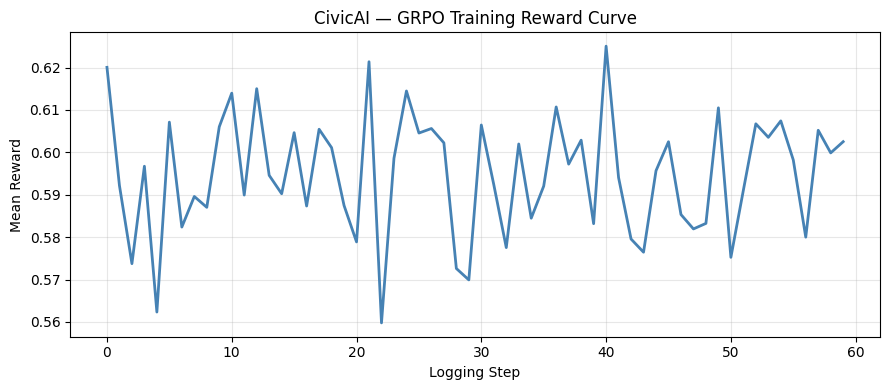

Final reward: 0.6025


In [35]:
# Extract reward from trainer log history
log_history = trainer.state.log_history
rewards_logged = [
    entry["reward"] for entry in log_history
    if "reward" in entry
]

if rewards_logged:
    plt.figure(figsize=(9, 4))
    plt.plot(rewards_logged, linewidth=2, color="steelblue")
    plt.xlabel("Logging Step")
    plt.ylabel("Mean Reward")
    plt.title("CivicAI — GRPO Training Reward Curve")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Final reward: {rewards_logged[-1]:.4f}")
else:
    print("No reward logs found — check logging_steps setting.")

In [36]:
def evaluate_policy(model, tokenizer, env, episodes=20, label=""):
    """Run the trained model on fresh environment states and collect rewards."""
    device = next(model.parameters()).device
    total_rewards = []

    for _ in range(episodes):
        state = env.reset()
        prompt = make_prompt(state)

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=200,
        ).to(device)

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=40,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        new_tokens = out[0][inputs["input_ids"].shape[1]:]
        text       = tokenizer.decode(new_tokens, skip_special_tokens=True)
        action     = parse_action(text)

        _, reward  = env.step(action)
        total_rewards.append(reward)

    mean_r = float(np.mean(total_rewards))
    print(f"{label:15s}  mean reward = {mean_r:.4f}  (over {episodes} episodes)")
    return mean_r

def baseline_random(env, episodes=20):
    """Fixed mid-point policy as baseline."""
    rewards = []
    for _ in range(episodes):
        env.reset()
        _, r = env.step({"tax": 0.5, "jobs": 0.5, "healthcare": 0.5})
        rewards.append(r)
    mean_r = float(np.mean(rewards))
    print(f"{'Baseline':15s}  mean reward = {mean_r:.4f}  (over {episodes} episodes)")
    return mean_r

baseline_score = baseline_random(env)
trained_score  = evaluate_policy(model, tokenizer, env, label="Trained (GRPO)")

print("\n--- Summary ---")
print(f"Baseline : {baseline_score:.4f}")
print(f"Trained  : {trained_score:.4f}")
print(f"Delta    : {trained_score - baseline_score:+.4f}")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Baseline         mean reward = 0.7210  (over 20 episodes)
Trained (GRPO)   mean reward = 0.6926  (over 20 episodes)

--- Summary ---
Baseline : 0.7210
Trained  : 0.6926
Delta    : -0.0284
